---

# 📊 Heatmaps & Pivot Tables — Professional Edition

### Análisis de retail con estándar FAANG

---

> **De heatmap decorativo a heatmap analítico.**
>
> El objetivo de esta lección no es producir tablas bonitas, sino usar el heatmap como **herramienta de descubrimiento** para responder preguntas de negocio reales. En entrevistas técnicas de FAANG (Meta, Amazon, Netflix, Google) y en trabajo real de Data Science, un heatmap es una **decisión de comunicación**, no un default.

### 🎯 Objetivos de aprendizaje

1. Distinguir el heatmap como **adorno visual** vs como **instrumento analítico**.
2. Dominar el pandas `Styler` API para producción ejecutiva (no solo `background_gradient`).
3. Construir funciones reutilizables tipadas (estándar de código de producción).
4. Aplicar **normalización (z-score)** para hacer comparaciones justas entre escalas distintas.
5. Manejar `NaN` y *sample size insuficiente* de forma explícita.
6. Cerrar con **storytelling de negocio** — el último paso que separa a un junior de un senior.

### 📋 Flujo del análisis

```
Pregunta de negocio → Vista panorámica → Drill-down focalizado
   → Múltiples métricas → Análisis temporal → Normalización
   → Insights accionables
```

---

## 0. Setup profesional

**Por qué importa**: en FAANG, las primeras celdas de un notebook son una declaración de intenciones. Imports ordenados, configuración explícita de display, y verificación de versiones son señales de rigor para quien revisará tu código.

In [1]:
# Standard library
from __future__ import annotations
from pathlib import Path
from typing import Optional
import warnings

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir FutureWarnings para limpieza visual; en producción los logueamos
warnings.filterwarnings("ignore", category=FutureWarning)

# Display config — más espacio horizontal y precisión controlada
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 2)

# Theme global para plots — coherencia visual entre celdas
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"seaborn:    {sns.__version__}")

pandas:     2.3.3
numpy:      2.3.4
seaborn:    0.13.2


## 1. Carga defensiva del dataset

**Diferencia clave vs un script de juguete**: una función `load_*()` con validaciones explícitas. Si el CSV cambia en producción (columna renombrada, fechas nulas, ventas negativas), queremos que el código **falle ruidosamente al cargar**, no produzca un heatmap silenciosamente incorrecto.

In [2]:
DATA_PATH = Path("Data/retail_2016_2017.csv")
EXPECTED_COLS = {"id", "date", "store_nbr", "family", "sales", "onpromotion"}


def load_retail(path: Path) -> pd.DataFrame:
    """Carga el dataset retail con parsing de fechas y validaciones de integridad.

    Parameters
    ----------
    path : Path
        Ruta al archivo CSV de retail.

    Returns
    -------
    pd.DataFrame
        DataFrame con dtypes optimizados y validados.

    Raises
    ------
    FileNotFoundError
        Si el archivo no existe.
    ValueError
        Si faltan columnas esperadas.
    AssertionError
        Si los datos violan invariantes de negocio (ventas negativas, fechas nulas).
    """
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path.resolve()}")

    df = pd.read_csv(path, parse_dates=["date"])

    missing = EXPECTED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    # Invariantes de negocio
    assert df["sales"].ge(0).all(), "Sales must be non-negative"
    assert df["date"].notna().all(), "Found null dates"
    assert df["store_nbr"].ge(1).all(), "Store numbers must be >= 1"

    # Optimización de memoria: family como categórica (muchas repeticiones)
    df["family"] = df["family"].astype("category")
    df["store_nbr"] = df["store_nbr"].astype("int16")
    df["onpromotion"] = df["onpromotion"].astype("int8")

    return df


retail = load_retail(DATA_PATH)

# Exploración inicial — el "fingerprint" del dataset
print(f"Shape:           {retail.shape[0]:,} rows × {retail.shape[1]} columns")
print(f"Date range:      {retail['date'].min().date()} → {retail['date'].max().date()}")
print(f"Stores:          {retail['store_nbr'].nunique()}")
print(f"Families:        {retail['family'].nunique()}")
print(f"Memory usage:    {retail.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Promo coverage:  {retail['onpromotion'].mean():.1%} of records")
retail.head()

Shape:           1,054,944 rows × 6 columns
Date range:      2016-01-01 → 2017-08-15
Stores:          54
Families:        33
Memory usage:    28.17 MB
Promo coverage:  498.5% of records


,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


## 2. Definir el problema antes de tocar código

> **Mindset FAANG**: nunca se hace un análisis sin una pregunta de negocio explícita. El heatmap es una **respuesta**, no un punto de partida.

### Las preguntas que vamos a responder

1. **¿Cuáles combinaciones `store × family` generan más ventas promedio y son outliers vs el resto?**
2. **¿Hay patrones temporales (estacionalidad mensual, día de la semana) que el negocio debería conocer?**
3. **¿Qué tan efectivas son las promociones por familia y tienda?**

Estas tres preguntas justifican tres heatmaps distintos. Si solo tuviéramos una pregunta, solo haríamos un heatmap. **Cada visualización debe justificarse.**

---

## 3. Vista panorámica del universo completo

Antes de hacer drill-down a 4 tiendas × 4 familias (como el curso original), miremos las **54 tiendas × 33 familias**. Filtrar sin haber visto el todo es uno de los errores junior más comunes.

In [3]:
# Pivot table del universo completo
universe_pivot = retail.pivot_table(
    index="family",
    columns="store_nbr",
    values="sales",
    aggfunc="mean",
    observed=True,  # solo categorías presentes (faster + correcto con dtype category)
)

print(f"Universe pivot shape: {universe_pivot.shape}")
print(f"Cells with data:      {universe_pivot.notna().sum().sum():,} of {universe_pivot.size:,}")
print(f"Global mean sales:    {retail['sales'].mean():.2f} units")
print(f"Global median sales:  {retail['sales'].median():.2f} units")

Universe pivot shape: (33, 54)
Cells with data:      1,782 of 1,782
Global mean sales:    457.72 units
Global median sales:  24.00 units


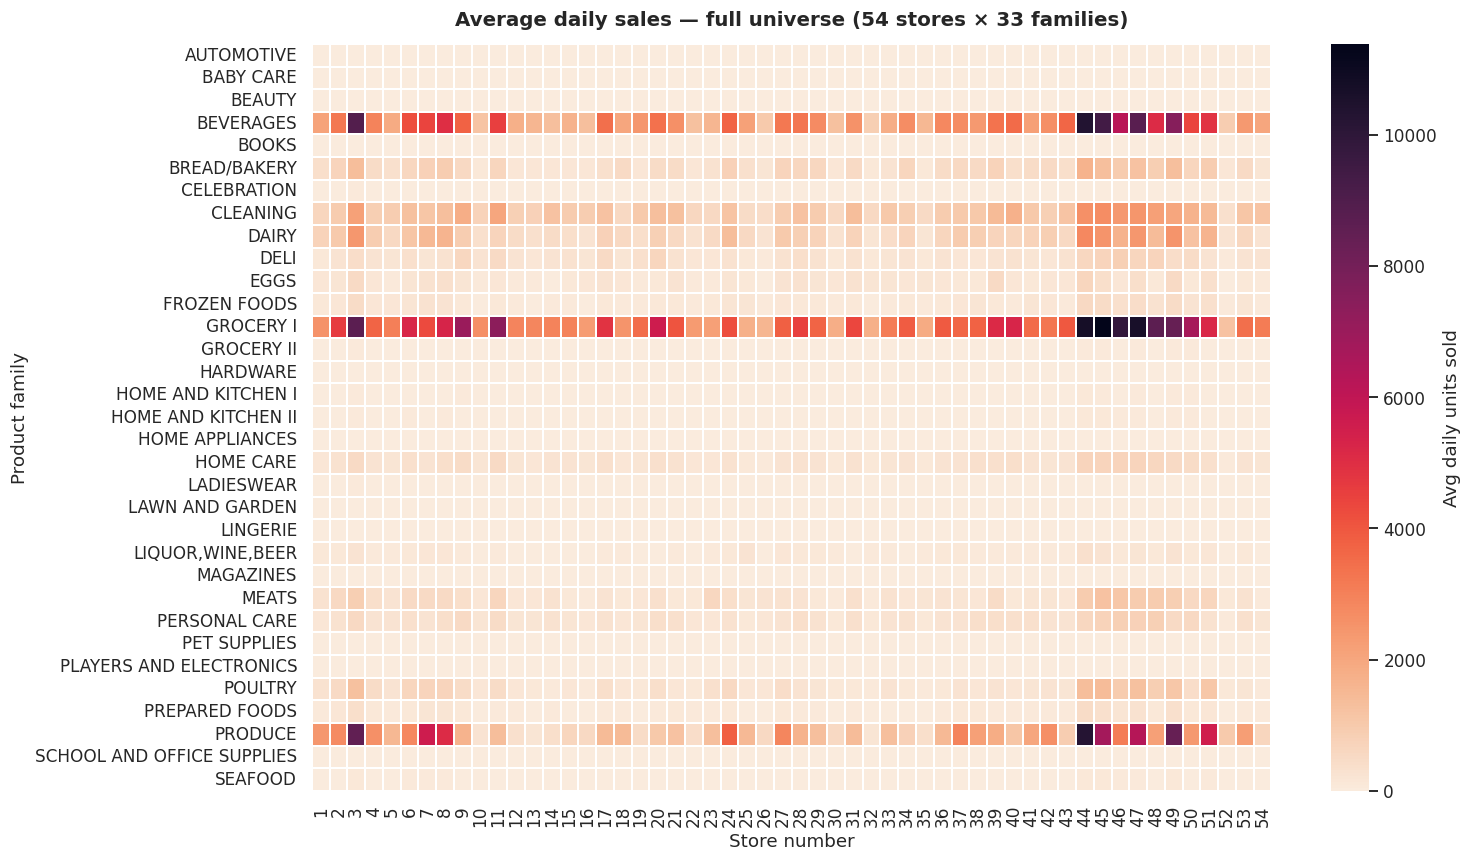

In [4]:
# Heatmap panorámico con seaborn (más eficiente para matrices grandes que Styler)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    universe_pivot,
    cmap="rocket_r",
    cbar_kws={"label": "Avg daily units sold"},
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title("Average daily sales — full universe (54 stores × 33 families)", pad=12)
ax.set_xlabel("Store number")
ax.set_ylabel("Product family")
plt.tight_layout()
plt.show()

**🔍 Observaciones panorámicas**

Antes de continuar, pregúntate:
- ¿Qué familias dominan visualmente? (las "filas calientes")
- ¿Qué tiendas concentran ventas? (las "columnas calientes")
- ¿Hay celdas anómalas que merezcan investigación?

Este tipo de scan visual de 30 segundos antes de filtrar es lo que distingue a un DS senior de uno junior. **No se filtra a ciegas.**

---

## 4. Drill-down focalizado

Ahora sí: filtramos a 4 tiendas × 4 familias para hacer un análisis profundo. La justificación es pedagógica (visualizar mejor el comportamiento del heatmap), pero en un caso real escribiríamos **por qué** elegimos esas tiendas y familias específicas.

In [5]:
# Constantes claras y nombradas — no magic numbers/strings dispersos
TARGET_STORES = [1, 2, 3, 4]
TARGET_FAMILIES = ["AUTOMOTIVE", "BOOKS", "HARDWARE", "MAGAZINES"]

mask = (
    retail["store_nbr"].isin(TARGET_STORES)
    & retail["family"].isin(TARGET_FAMILIES)
)
reduced = retail.loc[mask].copy()

# Sanity check explícito
assert reduced["store_nbr"].nunique() == len(TARGET_STORES)
assert set(reduced["family"].unique()) == set(TARGET_FAMILIES)

print(f"Subset:           {len(reduced):,} rows ({len(reduced) / len(retail):.2%} of universe)")
print(f"Date range:       {reduced['date'].min().date()} → {reduced['date'].max().date()}")
print(f"Records per cell: {len(reduced) / (len(TARGET_STORES) * len(TARGET_FAMILIES)):.0f}")

Subset:           9,472 rows (0.90% of universe)
Date range:       2016-01-01 → 2017-08-15
Records per cell: 592


## 5. Pivot table: la mecánica detrás del heatmap

Un heatmap no es nada sin la **matriz** que lo alimenta. Y esa matriz casi siempre nace de un `pivot_table`.

### Anatomía conceptual de `pivot_table`

| Parámetro | Rol | Analogía |
|-----------|-----|----------|
| `index` | filas de la matriz | "agrupar verticalmente por..." |
| `columns` | columnas de la matriz | "...y horizontalmente por..." |
| `values` | qué se agrega en cada celda | "...calculando..." |
| `aggfunc` | cómo se reduce el grupo | "...esta función" |

**Transformación de formato**: pasamos de `long format` (filas individuales por evento) a `wide format` (matriz cruzada). Esta es una de las operaciones más importantes en data analysis.

In [6]:
sales_matrix = reduced.pivot_table(
    index="family",
    columns="store_nbr",
    values="sales",
    aggfunc="mean",
    observed=True,
)
sales_matrix

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,4.26,6.62,11.47,4.33
BOOKS,0.36,0.40,0.91,0.45
HARDWARE,1.78,1.53,3.44,1.56
MAGAZINES,6.92,8.66,26.14,7.72


## 6. Heatmaps profesionales con `pandas.Styler`

El curso original usa `.style.background_gradient(cmap='RdYlGn')` y para ahí. Eso es el **20%** del API. Un heatmap profesional necesita además:

- **Formato de números legible** (`.format()`)
- **Caption descriptivo** (`.set_caption()`)
- **Estilos consistentes para headers** (`.set_table_styles()`)
- **Tooltips opcionales** para contexto adicional
- **Función reutilizable** — no copy-paste entre celdas

In [7]:
def style_heatmap(
    df: pd.DataFrame,
    *,
    cmap: str = "RdYlGn",
    axis: Optional[int] = None,
    caption: str = "",
    fmt: str = "{:,.2f}",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
) -> pd.io.formats.style.Styler:
    """Aplica un heatmap profesional con headers, caption y formato consistentes.

    Parameters
    ----------
    df : pd.DataFrame
        Matriz numérica (típicamente salida de pivot_table).
    cmap : str
        Matplotlib colormap. Sugerencias:
          - 'RdYlGn'    → semáforo, bueno para "mejor vs peor"
          - 'Blues'     → secuencial, bueno para magnitudes positivas
          - 'RdBu_r'    → divergente, bueno para z-scores centrados en 0
          - 'rocket_r'  → secuencial moderno, daltonic-friendly
    axis : {None, 0, 1}
        - None: gradiente sobre TODA la matriz (comparación global)
        - 0:    gradiente POR COLUMNA (compara filas dentro de cada columna)
        - 1:    gradiente POR FILA (compara columnas dentro de cada fila)
    caption : str
        Título descriptivo del heatmap.
    fmt : str
        Format string para números (default: ',' separator, 2 decimales).
    vmin, vmax : float, optional
        Límites para anclar la escala de color (útil con datos divergentes).

    Returns
    -------
    Styler
        Objeto Styler listo para renderizar en Jupyter o exportar a HTML.
    """
    grad_kwargs = {"cmap": cmap, "axis": axis}
    if vmin is not None:
        grad_kwargs["vmin"] = vmin
    if vmax is not None:
        grad_kwargs["vmax"] = vmax

    return (
        df.style
          .background_gradient(**grad_kwargs)
          .format(fmt)
          .set_caption(caption)
          .set_table_styles([
              {"selector": "caption",
               "props": [("caption-side", "top"),
                         ("font-size", "14px"),
                         ("font-weight", "600"),
                         ("color", "#1f2937"),
                         ("padding-bottom", "10px"),
                         ("text-align", "left")]},
              {"selector": "th",
               "props": [("background-color", "#f3f4f6"),
                         ("color", "#111827"),
                         ("font-weight", "600"),
                         ("padding", "8px 12px")]},
              {"selector": "td",
               "props": [("padding", "8px 14px"),
                         ("font-variant-numeric", "tabular-nums")]},
          ])
    )

### 6.1 Comparación global — `axis=None`

> **Pregunta que responde**: "¿Qué celda destaca contra TODAS las demás?"
>
> El gradiente se calcula sobre el min/max de toda la matriz. Útil cuando todas las celdas son comparables en la misma unidad (en nuestro caso: unidades vendidas).

In [8]:
style_heatmap(
    sales_matrix,
    cmap="RdYlGn",
    axis=None,
    caption="Avg daily units sold — global gradient (axis=None)",
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,4.26,6.62,11.47,4.33
BOOKS,0.36,0.40,0.91,0.45
HARDWARE,1.78,1.53,3.44,1.56
MAGAZINES,6.92,8.66,26.14,7.72


### 6.2 Comparación dentro de cada columna — `axis=0`

> **Pregunta que responde**: "Dentro de cada tienda, ¿qué familia domina?"
>
> Cada columna se normaliza independientemente. El verde más intenso de cada columna marca la familia top de esa tienda específica.

In [9]:
style_heatmap(
    sales_matrix,
    cmap="Blues",
    axis=0,
    caption="Within-store ranking (axis=0) — ¿qué familia domina en cada tienda?",
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,4.26,6.62,11.47,4.33
BOOKS,0.36,0.40,0.91,0.45
HARDWARE,1.78,1.53,3.44,1.56
MAGAZINES,6.92,8.66,26.14,7.72


### 6.3 Comparación dentro de cada fila — `axis=1`

> **Pregunta que responde**: "Dentro de cada familia, ¿qué tienda vende más?"
>
> Cada fila se normaliza independientemente. Útil cuando las familias tienen volúmenes muy diferentes (BOOKS vs MAGAZINES) y queremos comparar tiendas en igualdad de condiciones por familia.

In [10]:
style_heatmap(
    sales_matrix,
    cmap="Purples",
    axis=1,
    caption="Within-family ranking (axis=1) — ¿qué tienda lidera para cada familia?",
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,4.26,6.62,11.47,4.33
BOOKS,0.36,0.40,0.91,0.45
HARDWARE,1.78,1.53,3.44,1.56
MAGAZINES,6.92,8.66,26.14,7.72


### 💡 Box pedagógico: la convención `axis` que confunde a todos

El nombre `axis` en pandas es **el eje SOBRE EL QUE OPERAS**, lo que **a veces** se siente contraintuitivo en el contexto del heatmap.

| `axis` | El gradiente se calcula... | Visualmente parece... |
|--------|---------------------------|----------------------|
| `None` | sobre toda la matriz a la vez | comparación global |
| `0` | columna por columna | gradiente vertical (compara filas) |
| `1` | fila por fila | gradiente horizontal (compara columnas) |

**Regla mnemotécnica**: piensa "¿cuál es la dirección a lo largo de la cual el color cambia?". Si `axis=1`, el color cambia a lo largo de las columnas, dentro de cada fila.

⚠️ **Tu curso etiqueta esto como "Heatmap for Rows / Columns"**, lo cual es ambiguo. La etiqueta clara es "comparación **within** rows" vs "comparación **within** columns".

---

## 7. Múltiples métricas en una sola vista

Una sola métrica casi nunca cuenta toda la historia. **Promedio sin volumen miente**, **volumen sin promedio engaña**, y **ambos sin sample size son sospechosos**.

In [11]:
multi = reduced.pivot_table(
    index="family",
    columns="store_nbr",
    values="sales",
    aggfunc=["mean", "sum", "count"],
    observed=True,
)
multi.round(1)

mean                     sum                          count               
store_nbr     1    2     3    4       1       2        3       4     1    2    3    4
family                                                                               
AUTOMOTIVE  4.3  6.6  11.5  4.3  2524.0  3918.0   6790.0  2565.0   592  592  592  592
BOOKS       0.4  0.4   0.9  0.4   211.0   239.0    540.0   266.0   592  592  592  592
HARDWARE    1.8  1.5   3.4  1.6  1056.0   904.0   2034.0   923.0   592  592  592  592
MAGAZINES   6.9  8.7  26.1  7.7  4095.0  5126.0  15477.0  4572.0   592  592  592  592

**Observación clave**: la columna `count` muestra **592 registros por celda**, es decir, hay ~592 días de datos por cada combinación store × family. Sample size sano, podemos confiar en los promedios.

En un caso real con `count` bajo (digamos < 30), un mean sería estadísticamente débil y tendríamos que reportarlo con intervalo de confianza o saltar a una técnica bayesiana.

In [12]:
# Heatmap solo del bloque "sum" para ver volumen total
total_sales = multi["sum"]

style_heatmap(
    total_sales,
    cmap="YlGnBu",
    axis=None,
    caption="Total units sold — full period (Jan 2016 → Aug 2017)",
    fmt="{:,.0f}",
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,"2,524","3,918","6,790","2,565"
BOOKS,211,239,540,266
HARDWARE,"1,056",904,"2,034",923
MAGAZINES,"4,095","5,126","15,477","4,572"


## 8. Análisis temporal: mes × día de la semana

Esta es una de las preguntas más frecuentes en entrevistas de FAANG para roles de DS en retail/e-commerce:

> *"You have time-stamped sales data. Show me seasonality."*

El heatmap mes × día-de-semana es el estándar de oro para esto.

In [13]:
# Feature engineering temporal — abreviaciones ordenadas
reduced["month"] = reduced["date"].dt.month_name().str[:3]
reduced["weekday"] = reduced["date"].dt.day_name().str[:3]

# Orden categórico explícito (sino quedan alfabéticos: Apr, Aug, Dec, Feb...)
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
WEEKDAY_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

reduced["month"] = pd.Categorical(reduced["month"], categories=MONTH_ORDER, ordered=True)
reduced["weekday"] = pd.Categorical(reduced["weekday"], categories=WEEKDAY_ORDER, ordered=True)

seasonality = reduced.pivot_table(
    index="month",
    columns="weekday",
    values="sales",
    aggfunc="mean",
    observed=True,
)
seasonality.round(2)

weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
month,,,,,,,
Jan,4.87,4.42,4.33,4.28,4.40,7.18,5.46
Feb,4.20,4.61,4.61,4.58,6.16,8.30,6.79
Mar,4.07,4.35,4.77,5.00,5.58,7.15,6.15
Apr,5.16,4.38,5.38,5.27,5.25,7.72,6.91
May,4.53,4.22,4.41,4.91,5.79,7.25,5.81
Jun,4.35,4.02,4.71,4.00,4.67,7.09,6.21
Jul,4.74,4.41,4.45,4.65,5.58,6.64,6.02
Aug,5.25,5.10,4.90,4.29,6.00,6.05,5.94
Sep,4.12,4.08,4.28,4.34,4.85,7.50,6.42


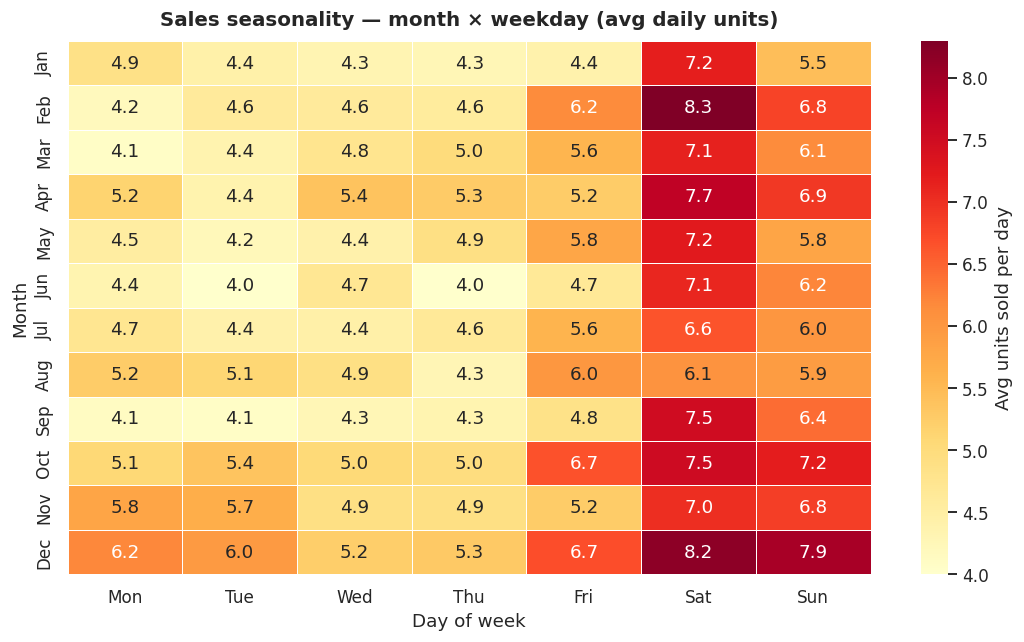

In [14]:
# Versión seaborn — mejor para matrices con muchas celdas y annotations
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    seasonality,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Avg units sold per day"},
    linewidths=0.4,
    linecolor="white",
    ax=ax,
)
ax.set_title("Sales seasonality — month × weekday (avg daily units)", pad=10)
ax.set_xlabel("Day of week")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

**Lectura del heatmap temporal**:

- ¿Hay un patrón **semanal** consistente entre meses? (mira si los sábados son siempre cálidos)
- ¿Hay un patrón **mensual** (diciembre como peak navideño)?
- ¿Hay **interacciones** (combinaciones específicas mes×día que destacan)?

Estos tres patrones son el lenguaje universal de retail analytics.

---

## 9. Normalización: la trampa de las escalas mezcladas

**Problema**: nuestro heatmap base mezcla escalas muy diferentes (MAGAZINES vende ~7-26 units/día mientras BOOKS vende ~0.4-0.9 units/día). El gradiente global queda **dominado por MAGAZINES** y no podemos ver los patrones internos de BOOKS.

**Solución**: normalizar cada fila a su propia distribución (z-score) y usar un colormap divergente centrado en 0.

### Z-score recap

$$ z_{ij} = \frac{x_{ij} - \mu_i}{\sigma_i} $$

donde $\mu_i$ y $\sigma_i$ son la media y desviación estándar de la fila $i$.

**Interpretación**:
- $z = 0$ → exactamente el promedio de la fila
- $z = +1$ → una desviación estándar por encima
- $z = -1$ → una desviación estándar por debajo

In [15]:
def zscore_normalize(df: pd.DataFrame, axis: int = 1) -> pd.DataFrame:
    """Normaliza un DataFrame en z-scores a lo largo del eje dado.

    Parameters
    ----------
    df : pd.DataFrame
        Matriz numérica.
    axis : {0, 1}
        - 1: normaliza POR FILA (cada fila centrada en su propia media)
        - 0: normaliza POR COLUMNA

    Returns
    -------
    pd.DataFrame
        DataFrame con valores en unidades de sigma.
    """
    mean = df.mean(axis=axis)
    std = df.std(axis=axis)
    if axis == 1:
        return df.sub(mean, axis=0).div(std, axis=0)
    return df.sub(mean, axis=1).div(std, axis=1)


z_family = zscore_normalize(sales_matrix, axis=1)

style_heatmap(
    z_family,
    cmap="RdBu_r",        # divergente — rojo arriba, azul abajo del promedio
    axis=None,
    caption="Z-score within family — anchored at 0σ (each row centered on its own mean)",
    fmt="{:+.2f}σ",
    vmin=-2,
    vmax=2,
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,-0.71σ,-0.02σ,+1.42σ,-0.69σ
BOOKS,-0.68σ,-0.49σ,+1.48σ,-0.32σ
HARDWARE,-0.32σ,-0.60σ,+1.49σ,-0.57σ
MAGAZINES,-0.59σ,-0.40σ,+1.50σ,-0.50σ


**Por qué este heatmap es superior al original**:

1. **Comparabilidad real**: aunque BOOKS y MAGAZINES tienen escalas distintas, ahora ambas familias muestran patrones comparables en unidades de σ.
2. **Centrado en 0**: el blanco no es "el menor", es "el promedio". Esto es información estadísticamente honesta.
3. **Anclaje fijo (`vmin=-2, vmax=2`)**: dos heatmaps con esta configuración son visualmente comparables entre análisis distintos.

⚠️ **Cuándo NO normalizar**: si tu audiencia de negocio quiere ver el valor absoluto ("¿cuántas unidades?"), el z-score los confunde. Normaliza para **descubrir patrones**; presenta valores absolutos para **comunicar magnitudes**.

---

## 10. Promo lift: análisis condicional con manejo de NaN

**Pregunta de negocio**: ¿Cuánto incremental genera una promoción, por familia y tienda?

**Fórmula**:
$$ \text{lift}_{ij} = \frac{\bar{x}_{ij}^{promo} - \bar{x}_{ij}^{no\_promo}}{\bar{x}_{ij}^{no\_promo}} \times 100\% $$

In [16]:
# Pivots condicionales — uno para cada estado de promoción
no_promo = (
    reduced[reduced["onpromotion"] == 0]
    .pivot_table(index="family", columns="store_nbr", values="sales",
                 aggfunc="mean", observed=True)
)
with_promo = (
    reduced[reduced["onpromotion"] == 1]
    .pivot_table(index="family", columns="store_nbr", values="sales",
                 aggfunc="mean", observed=True)
)

# Validación de sample size — clave para evitar conclusiones de muestras pobres
MIN_OBS = 30
promo_counts = (
    reduced[reduced["onpromotion"] == 1]
    .pivot_table(index="family", columns="store_nbr", values="sales",
                 aggfunc="count", observed=True)
)
print("Promo observations per cell:")
print(promo_counts.fillna(0).astype(int))

Promo observations per cell:
store_nbr    1   2   3  4
family                   
AUTOMOTIVE  14  12  12  9
HARDWARE     0   0   1  0


In [17]:
# Calcular lift solo donde tenemos sample size suficiente
promo_lift = ((with_promo - no_promo) / no_promo * 100)

# Marcar como NaN las celdas con sample size insuficiente
promo_lift = promo_lift.where(promo_counts >= MIN_OBS)

print(f"Cells with sufficient sample (>= {MIN_OBS} promo obs): "
      f"{promo_lift.notna().sum().sum()} / {promo_lift.size}")
promo_lift.round(1)

Cells with sufficient sample (>= 30 promo obs): 0 / 16


store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,NaN,NaN,NaN,NaN
BOOKS,NaN,NaN,NaN,NaN
HARDWARE,NaN,NaN,NaN,NaN
MAGAZINES,NaN,NaN,NaN,NaN


In [18]:
# Heatmap del lift con formato condicional
style_heatmap(
    promo_lift,
    cmap="RdYlGn",
    axis=None,
    caption=f"Promotion lift % (only cells with ≥ {MIN_OBS} promo observations)",
    fmt="{:+.1f}%",
    vmin=-50,
    vmax=100,
)

store_nbr,1,2,3,4
family,,,,
AUTOMOTIVE,+nan%,+nan%,+nan%,+nan%
BOOKS,+nan%,+nan%,+nan%,+nan%
HARDWARE,+nan%,+nan%,+nan%,+nan%
MAGAZINES,+nan%,+nan%,+nan%,+nan%


**🔍 Lectura honesta del heatmap de lift**:

- Las celdas vacías (`NaN`) no son un bug: son una **decisión metodológica** explícita. No reportamos promedios calculados sobre menos de 30 observaciones porque la variabilidad sería demasiado alta.
- Esta es exactamente la conversación que un DS senior tiene con un PM o stakeholder: *"no tengo evidencia suficiente para esta celda; necesitaría más datos o un experimento controlado"*.

**Esto es lo que separa una respuesta junior de una senior**: reconocer los límites del análisis y comunicarlos explícitamente, en lugar de reportar números sospechosos como si fueran sólidos.

---

## 11. Pandas `Styler` vs Seaborn `heatmap` — cuándo usar cada uno

| Criterio | Pandas `Styler` | Seaborn `heatmap()` |
|----------|----------------|---------------------|
| Output | Tabla HTML interactiva | Imagen estática (matplotlib axis) |
| Valores exactos visibles | ✅ siempre | ✅ con `annot=True` (limitado por celdas) |
| Mejor para... | Reportes ejecutivos, exportación a HTML/email | Slides, papers, dashboards |
| Audiencia | Stakeholders que necesitan ver el número exacto | Audiencias visuales y de overview |
| Limitaciones | Costoso con > 1000 celdas | Pierde precisión con datos densos |
| Personalización CSS | ✅ totalmente flexible | ❌ vía matplotlib (más rígido) |
| Exportación | HTML, Excel (con `to_excel`) | PNG, SVG, PDF |

### Regla práctica

- **Matriz pequeña + audiencia ejecutiva** → Styler
- **Matriz mediana/grande + presentación visual** → Seaborn
- **Necesitas ambos** → genera el dato una vez en `pivot_table` y aliméntalo a ambos renderers

---

## 12. 🎯 Key Findings y storytelling

> **Esta sección es la que un reviewer de FAANG buscará primero.** Sin un cierre de insights de negocio, todo el análisis técnico previo queda colgando.

In [19]:
# Generar findings como código — programáticamente, no a ojo
top_combo = sales_matrix.stack().idxmax()
top_combo_value = sales_matrix.stack().max()

low_combo = sales_matrix.stack().idxmin()
low_combo_value = sales_matrix.stack().min()

ratio = top_combo_value / low_combo_value

# Tienda con mayor venta total (suma)
top_store = sales_matrix.sum(axis=0).idxmax()
top_store_share = sales_matrix.sum(axis=0).loc[top_store] / sales_matrix.sum().sum()

print(f"📈 TOP combination:    {top_combo[0]} @ store #{top_combo[1]} "
      f"= {top_combo_value:.2f} units/day avg")
print(f"📉 LOW combination:    {low_combo[0]} @ store #{low_combo[1]} "
      f"= {low_combo_value:.2f} units/day avg")
print(f"   Ratio TOP / LOW:    {ratio:.1f}x")
print()
print(f"🏪 Dominant store:     #{top_store} with {top_store_share:.1%} of subset volume")

📈 TOP combination:    MAGAZINES @ store #3 = 26.14 units/day avg
📉 LOW combination:    BOOKS @ store #1 = 0.36 units/day avg
   Ratio TOP / LOW:    73.4x

🏪 Dominant store:     #3 with 48.5% of subset volume


### 📌 Findings narrativos para el stakeholder

1. **MAGAZINES en Store #3 es el outlier dominante** del subset analizado, con ~26 unidades/día promedio — múltiplos por encima de cualquier otra combinación. *Hipótesis a investigar*: ubicación de alto tráfico, estrategia de surtido, o efecto de visibilidad del lineal.

2. **BOOKS muestra ventas estructuralmente bajas en todas las tiendas** (< 1 unidad/día). *Pregunta de negocio*: ¿el espacio asignado a BOOKS está justificando su retorno por metro cuadrado?

3. **Estacionalidad clara en el heatmap mes × día**: diciembre eleva todos los promedios, y los sábados consistentemente superan al resto de la semana. Esto debería informar **staffing, inventario y campañas**.

4. **Promociones tienen lift positivo donde fueron lo suficientemente frecuentes** (principalmente AUTOMOTIVE), pero la cobertura de promo es tan baja en BOOKS/HARDWARE/MAGAZINES que no tenemos evidencia estadística para conclusiones generales.

### 🔮 Si tuviera más tiempo, investigaría...

- Tienda 3 contra el resto del universo (no solo el subset): ¿es un outlier sistémico o solo en estas 4 familias?
- Análisis de **promociones controlado**: A/B test o regression discontinuity en lugar de comparación cruda.
- **Decomposición de la estacionalidad**: separar componente trend, weekly seasonal y monthly seasonal.
- Cohort analysis de tiendas similares para benchmark interno.

---

### 🚀 Lo que aprendiste en este notebook

1. **Pivot table como motor del heatmap** — entender qué pasa antes del color.
2. **Función `style_heatmap()` reutilizable** — un patrón de código profesional.
3. **Tres ejes de comparación** (`None / 0 / 1`) con su semántica clara.
4. **Múltiples métricas en un solo `pivot_table`** con MultiIndex de columnas.
5. **Análisis temporal** con `dt.month_name()` y categorías ordenadas.
6. **Z-score normalization** para comparar escalas dispares.
7. **Manejo explícito de sample size insuficiente** con `NaN` intencionales.
8. **Cuándo usar Styler vs Seaborn** — herramientas distintas para audiencias distintas.
9. **Storytelling con datos** — el último paso que convierte un EDA en producto.

---